In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

print(train.shape, test.shape)
train.head()

(198000, 15) (102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


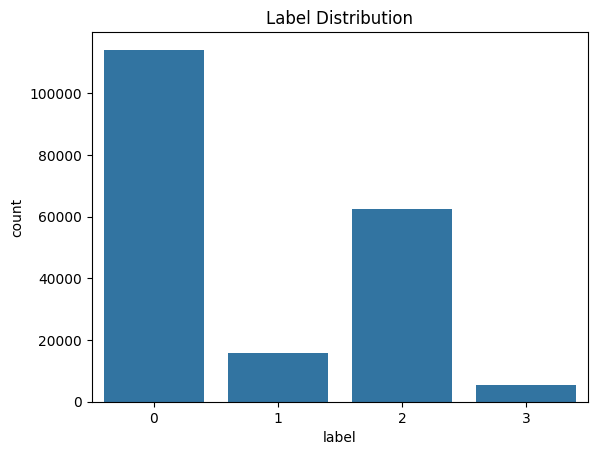

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64


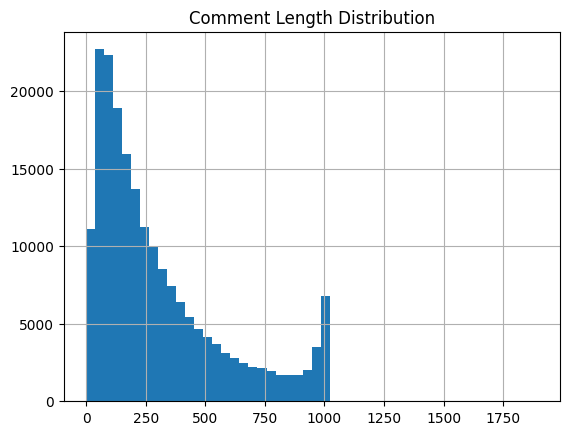

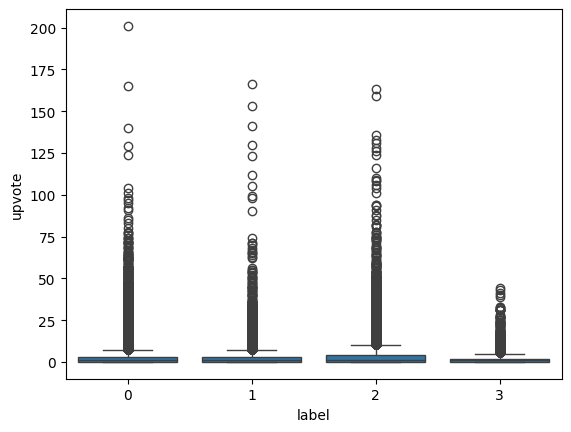

In [3]:
# Target distribution
sns.countplot(x="label", data=train)
plt.title("Label Distribution")
plt.show()

# Missing values
print(train.isnull().sum())

# Comment length
train["comment_length"] = train["comment"].fillna("").apply(len)
train["comment_length"].hist(bins=50)
plt.title("Comment Length Distribution")
plt.show()

# Upvotes vs label
sns.boxplot(x="label", y="upvote", data=train)
plt.show()

In [4]:
# Fill missing
train["comment"] = train["comment"].fillna("")
test["comment"] = test["comment"].fillna("")

# Handle categorical properly
for col in ["race", "religion", "gender"]:
    train[col] = train[col].astype(str)
    test[col] = test[col].astype(str)

train = pd.get_dummies(train, columns=["race", "religion", "gender"])
test = pd.get_dummies(test, columns=["race", "religion", "gender"])

# Align columns
train, test = train.align(test, join='left', axis=1, fill_value=0)

In [5]:
for df in [train, test]:
    df["comment_length"] = df["comment"].apply(len)
    df["word_count"] = df["comment"].str.split().str.len()
    df["excl"] = df["comment"].str.count("!")
    df["ques"] = df["comment"].str.count(r"\?")
    df["caps"] = df["comment"].apply(lambda x: sum(1 for c in x if c.isupper()))

In [6]:
train["created_date"] = pd.to_datetime(train["created_date"])
test["created_date"] = pd.to_datetime(test["created_date"])

for df in [train, test]:
    df["hour"] = df["created_date"].dt.hour
    df["dayofweek"] = df["created_date"].dt.dayofweek

In [7]:
word_tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    stop_words="english",
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3,5),
    max_features=20000
)

X_word = word_tfidf.fit_transform(train["comment"])
X_test_word = word_tfidf.transform(test["comment"])

X_char = char_tfidf.fit_transform(train["comment"])
X_test_char = char_tfidf.transform(test["comment"])

In [8]:
# Numeric features
num_cols = [col for col in train.columns if col not in ["comment","label","created_date"]]

X_num = train[num_cols]
X_test_num = test[num_cols]

# Convert safely
X_num = X_num.apply(pd.to_numeric, errors="coerce").fillna(0).astype("float32")
X_test_num = X_test_num.apply(pd.to_numeric, errors="coerce").fillna(0).astype("float32")

# Now safe
X = hstack([X_word, X_char, X_num])
X_test = hstack([X_test_word, X_test_char, X_test_num])

In [9]:
le = LabelEncoder()
y = le.fit_transform(train["label"])

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [11]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_val)
dummy_acc = accuracy_score(y_val, dummy_pred)

print("Dummy Accuracy:", dummy_acc)

Dummy Accuracy: 0.5766414141414141


In [12]:
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_val)
nb_acc = accuracy_score(y_val, nb_pred)

print("NB Accuracy:", nb_acc)

NB Accuracy: 0.4535858585858586


In [13]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_val)
lr_acc = accuracy_score(y_val, lr_pred)

print("LR Accuracy:", lr_acc)

LR Accuracy: 0.8751515151515151


In [14]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=700,
    learning_rate=0.03,
    num_leaves=80,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_val)
lgb_acc = accuracy_score(y_val, lgb_pred)

print("LGB Accuracy:", lgb_acc)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 83.823351 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5544690
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 43542
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

In [15]:
results = pd.DataFrame({
    "Model": ["Dummy", "Naive Bayes", "Logistic", "LightGBM"],
    "Accuracy": [dummy_acc, nb_acc, lr_acc, lgb_acc]
})

print(results)

         Model  Accuracy
0        Dummy  0.576641
1  Naive Bayes  0.453586
2     Logistic  0.875152
3     LightGBM  0.916566


In [16]:
nb_prob = nb.predict_proba(X_val)
lgb_prob = lgb_model.predict_proba(X_val)
lr_prob = lr.predict_proba(X_val)

# weighted ensemble (improved)
final_prob = 0.1*nb_prob + 0.2*lr_prob + 0.7*lgb_prob

final_pred = np.argmax(final_prob, axis=1)

print("Ensemble Accuracy:", accuracy_score(y_val, final_pred))

Ensemble Accuracy: 0.913510101010101


In [17]:
nb.fit(X, y)
lr.fit(X, y)
lgb_model.fit(X, y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 186.203154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5988189
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 48615
[LightGBM] [Info] Start training from score -0.550552
[LightGBM] [Info] Start training from score -2.520816
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589171
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, max_depth=10,
               n_estimators=700, num_leaves=80, random_state=42, subsample=0.8)

In [18]:
nb_test = nb.predict_proba(X_test)
lr_test = lr.predict_proba(X_test)
lgb_test = lgb_model.predict_proba(X_test)

final_test = 0.1*nb_test + 0.2*lr_test + 0.7*lgb_test

pred = np.argmax(final_test, axis=1)
pred = le.inverse_transform(pred)

In [19]:
sample["label"] = pred
sample.to_csv("submission.csv", index=False)

print("Submission file created!")

Submission file created!
